In [ ]:
import numpy as np
import pandas as pd

In [ ]:
train_data = pd.read_csv("/content/fashion-mnist_test.csv")
test_data = pd.read_csv("/content/fashion-mnist_train.csv")

X_train = train_data.iloc[:, 1:].values / 255.0
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values / 255.0
y_test = test_data.iloc[:, 0].values

X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

print("Training Shape:", X_train.shape)


Training Shape: (10000, 1, 28, 28)


In [ ]:
class ConvLayer:
    def __init__(self, num_filters, filter_size):
        self.num_filters = num_filters
        self.filter_size = filter_size
        self.filters = np.random.randn(num_filters, 1, filter_size, filter_size) * 0.1

    def forward(self, input):
        self.input = input
        batch, _, h, w = input.shape
        self.output = np.zeros((batch, self.num_filters, h-2, w-2))

        for b in range(batch):
            for f in range(self.num_filters):
                for i in range(h-2):
                    for j in range(w-2):
                        region = input[b, :, i:i+3, j:j+3]
                        self.output[b, f, i, j] = np.sum(region * self.filters[f])
        return self.output

    def backward(self, d_out, lr):
        d_filters = np.zeros_like(self.filters)

        batch, _, h, w = self.input.shape

        for b in range(batch):
            for f in range(self.num_filters):
                for i in range(h-2):
                    for j in range(w-2):
                        region = self.input[b, :, i:i+3, j:j+3]
                        d_filters[f] += d_out[b, f, i, j] * region

        self.filters -= lr * d_filters

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_backward(d_out, x):
    d = d_out.copy()
    d[x <= 0] = 0
    return d

In [ ]:
class MaxPool:
    def forward(self, input):
        self.input = input
        batch, filters, h, w = input.shape
        self.output = np.zeros((batch, filters, h//2, w//2))

        for b in range(batch):
            for f in range(filters):
                for i in range(0, h, 2):
                    for j in range(0, w, 2):
                        region = input[b, f, i:i+2, j:j+2]
                        self.output[b, f, i//2, j//2] = np.max(region)
        return self.output

    def backward(self, d_out):
        batch, filters, h, w = self.input.shape
        d_input = np.zeros_like(self.input)

        for b in range(batch):
            for f in range(filters):
                for i in range(0, h, 2):
                    for j in range(0, w, 2):
                        region = self.input[b, f, i:i+2, j:j+2]
                        max_val = np.max(region)

                        for x in range(2):
                            for y in range(2):
                                if region[x, y] == max_val:
                                    d_input[b, f, i+x, j+y] = d_out[b, f, i//2, j//2]

        return d_input


In [ ]:

class FullyConnected:
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(input_size, output_size) * 0.1
        self.bias = np.zeros(output_size)

    def forward(self, input):
        self.input = input
        return np.dot(input, self.weights) + self.bias

    def backward(self, d_out, lr):
        d_weights = np.dot(self.input.T, d_out)
        d_bias = np.sum(d_out, axis=0)
        d_input = np.dot(d_out, self.weights.T)

        self.weights -= lr * d_weights
        self.bias -= lr * d_bias

        return d_input

In [ ]:
def softmax(x):
    exp = np.exp(x - np.max(x))
    return exp / np.sum(exp)

def cross_entropy(pred, label):
    return -np.log(pred[label] + 1e-9)


In [ ]:
conv = ConvLayer(8, 3)
pool = MaxPool()
fc = FullyConnected(8 * 13 * 13, 10)

learning_rate = 0.005
epochs = 10
train_samples = 5000

In [ ]:
for epoch in range(epochs):

    correct = 0
    total_loss = 0

    for i in range(train_samples):

        image = X_train[i:i+1]
        label = y_train[i]

        # Forward
        out_conv = conv.forward(image)
        out_relu = relu(out_conv)
        out_pool = pool.forward(out_relu)

        out_flat = out_pool.reshape(1, -1)
        out_fc = fc.forward(out_flat)

        probs = softmax(out_fc[0])

        loss = cross_entropy(probs, label)
        total_loss += loss

        if np.argmax(probs) == label:
            correct += 1

        # Backward
        d_out = probs.copy()
        d_out[label] -= 1
        d_out = d_out.reshape(1, -1)

        d_fc = fc.backward(d_out, learning_rate)
        d_pool = d_fc.reshape(out_pool.shape)

        d_relu = pool.backward(d_pool)
        d_conv = relu_backward(d_relu, out_conv)

        conv.backward(d_conv, learning_rate)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Loss:", total_loss/train_samples)
    print("Training Accuracy:", correct/train_samples)


Epoch 1/10
Loss: 0.925862310330366
Training Accuracy: 0.6718

Epoch 2/10
Loss: 0.6050287169369216
Training Accuracy: 0.7938

Epoch 3/10
Loss: 0.5111688426377657
Training Accuracy: 0.8234

Epoch 4/10
Loss: 0.4596921347027068
Training Accuracy: 0.8358

Epoch 5/10
Loss: 0.42452275914364646
Training Accuracy: 0.8462

Epoch 6/10
Loss: 0.3976728323822887
Training Accuracy: 0.8596

Epoch 7/10
Loss: 0.37569438121489945
Training Accuracy: 0.8672

Epoch 8/10
Loss: 0.35694799712887154
Training Accuracy: 0.872

Epoch 9/10
Loss: 0.3399260019610114
Training Accuracy: 0.8802

Epoch 10/10
Loss: 0.3247503906710106
Training Accuracy: 0.8844


In [ ]:
correct = 0
test_samples = 2000

for i in range(test_samples):

    image = X_test[i:i+1]
    label = y_test[i]

    out = conv.forward(image)
    out = relu(out)
    out = pool.forward(out)
    out = out.reshape(1, -1)
    out = fc.forward(out)

    probs = softmax(out[0])

    if np.argmax(probs) == label:
        correct += 1

print("\nFinal Test Accuracy:", correct/test_samples)



Final Test Accuracy: 0.8145


In [ ]:
fashion_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [ ]:
import matplotlib.pyplot as plt

def show_fashion_images(X, y_true, y_pred, class_names, num_images=10):
    plt.figure(figsize=(15, 6))

    for i in range(num_images):
        plt.subplot(2, 5, i + 1)

        img = X[i].squeeze()
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)

        plt.title(
            f"Pred: {class_names[y_pred[i]]}\nTrue: {class_names[y_true[i]]}",
            fontsize=10
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
train_data = pd.read_csv("/content/fashion-mnist_train.csv")
test_data  = pd.read_csv("/content/fashion-mnist_test.csv")

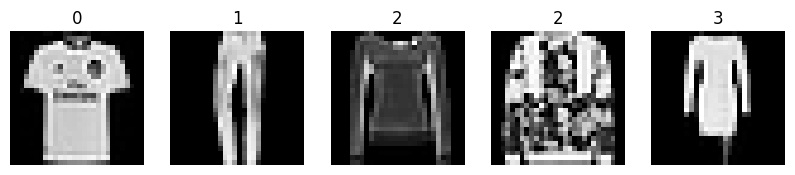

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

# Display first 5 images from X_train
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i][0], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()